In [1]:
# Imports & Configuration

import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.signal as signal
import scipy.stats as stats
from scipy.interpolate import interp1d

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Stochastic / signal analysis
from scipy.linalg import solve_continuous_are
from numpy.random import default_rng

# Paths
MMASH_PATH = r"C:\Users\Salome\Documents\MY PROJECTS\cross_organ_sync\mmash_data"
RESULTS_PATH = "./results/"
os.makedirs(RESULTS_PATH, exist_ok=True)

# Constants
N_SUBJECTS = 22
FS_RR      = 4        # Hz - resampling rate for RR intervals
FS_ACCEL   = 32       # Hz - accelerometer native rate
WINDOW_SEC = 300      # 5-min analysis windows
OVERLAP    = 0.5      # 50% overlap

rng = default_rng(42)
print("✅ Environment ready")
print(f"MMASH path exists: {os.path.exists(MMASH_PATH)}")

✅ Environment ready
MMASH path exists: True


In [2]:
# Subject Discovery & Data Inventory

def get_subject_dirs(base_path):
    """Find all user_X directories."""
    pattern = os.path.join(base_path, "user_*")
    dirs = sorted(glob.glob(pattern))
    return dirs

subject_dirs = get_subject_dirs(MMASH_PATH)
print(f"Found {len(subject_dirs)} subject directories\n")

# Inventory available files per subject
inventory = []
expected_files = ["RR.csv", "Actigraph.csv", "saliva.csv", 
                  "sleep.csv", "questionnaire.csv"]

for s_dir in subject_dirs:
    sid = os.path.basename(s_dir)
    row = {"subject": sid}
    for f in expected_files:
        fpath = os.path.join(s_dir, "datafile", f)
        # MMASH nests files differently per subject — check both layouts
        if not os.path.exists(fpath):
            fpath = os.path.join(s_dir, f)
        row[f] = os.path.exists(fpath)
    inventory.append(row)

df_inv = pd.DataFrame(inventory)
print(df_inv.to_string(index=False))
print(f"\nComplete subjects (all files): "
      f"{df_inv[expected_files].all(axis=1).sum()}/{len(df_inv)}")

Found 22 subject directories

subject  RR.csv  Actigraph.csv  saliva.csv  sleep.csv  questionnaire.csv
 user_1    True           True        True       True               True
user_10    True           True        True       True               True
user_11    True           True        True       True               True
user_12    True           True        True       True               True
user_13    True           True        True       True               True
user_14    True           True        True       True               True
user_15    True           True        True       True               True
user_16    True           True        True       True               True
user_17    True           True        True       True               True
user_18    True           True        True       True               True
user_19    True           True        True       True               True
 user_2    True           True        True       True               True
user_20    True      

In [3]:
# DIAGNOSTIC CELL - run this before fixing Cell 3
import pandas as pd, os

sample_dir = subject_dirs[0]
for layout in ["datafile/RR.csv", "RR.csv"]:
    fpath = os.path.join(sample_dir, layout)
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        print(f"Found at: {fpath}")
        print(f"Columns: {df.columns.tolist()}")
        print(df.head())
        break

Found at: C:\Users\Salome\Documents\MY PROJECTS\cross_organ_sync\mmash_data\user_1\RR.csv
Columns: ['Unnamed: 0', 'ibi_s', 'day', 'time']
   Unnamed: 0  ibi_s  day      time
0           1  0.258    1  10:10:17
1           2  0.319    1  10:10:18
2           3  0.266    1  10:10:18
3           4  0.401    1  10:10:18
4           5  1.089    1  10:10:19


In [4]:
# Load RR Interval Data 

def time_to_seconds(t_str):
    """Convert HH:MM:SS string to total seconds."""
    h, m, s = str(t_str).split(":")
    return int(h) * 3600 + int(m) * 60 + float(s)

def load_rr(subject_dir):
    for layout in ["datafile/RR.csv", "RR.csv"]:
        fpath = os.path.join(subject_dir, layout)
        if os.path.exists(fpath):
            df = pd.read_csv(fpath)
            df.columns = df.columns.str.strip().str.lower()

            # Convert ibi from seconds → milliseconds
            df["rr_ms"] = df["ibi_s"] * 1000

            # Convert HH:MM:SS → cumulative seconds
            df["time_s"] = df["time"].apply(time_to_seconds)
            # Handle midnight rollover across days
            if "day" in df.columns:
                df["time_s"] += (df["day"] - 1) * 86400

            # Physiological filter: 300–2000 ms
            df = df[(df["rr_ms"] >= 300) & (df["rr_ms"] <= 2000)].copy()
            df = df.dropna(subset=["rr_ms","time_s"]).reset_index(drop=True)
            return df
    return None

# Load all subjects
rr_data = {}
for s_dir in subject_dirs:
    sid = os.path.basename(s_dir)
    df = load_rr(s_dir)
    if df is not None and len(df) > 100:
        rr_data[sid] = df

print(f"Successfully loaded RR data: {len(rr_data)}/{len(subject_dirs)} subjects")

for sid, df in list(rr_data.items())[:3]:
    print(f"  {sid}: {len(df)} beats | "
          f"mean RR = {df['rr_ms'].mean():.1f} ms | "
          f"duration = {df['time_s'].max()/3600:.1f} hrs")

Successfully loaded RR data: 22/22 subjects
  user_1: 91419 beats | mean RR = 713.8 ms | duration = 33.8 hrs
  user_10: 67751 beats | mean RR = 822.7 ms | duration = 33.3 hrs
  user_11: 76749 beats | mean RR = 856.5 ms | duration = 33.5 hrs


In [5]:
# Load Accelerometer

def load_actigraph(subject_dir):
    for layout in ["datafile/Actigraph.csv", "Actigraph.csv"]:
        fpath = os.path.join(subject_dir, layout)
        if os.path.exists(fpath):
            df = pd.read_csv(fpath)
            df.columns = df.columns.str.strip().str.lower()

            # Rename vector magnitude → magnitude
            if "vector magnitude" in df.columns:
                df = df.rename(columns={"vector magnitude": "magnitude"})

            # Find time column whatever it's named and convert to seconds
            time_col = [c for c in df.columns if 'time' in c]
            if time_col:
                df = df.rename(columns={time_col[0]: "time_s"})
                df["time_s"] = df["time_s"].apply(time_to_seconds)

            # Add day offset
            if "day" in df.columns:
                df["time_s"] = df["time_s"] + (df["day"] - 1) * 86400

            df = df.dropna(subset=["magnitude", "time_s"]).reset_index(drop=True)
            return df
    return None

accel_data = {}
for s_dir in subject_dirs:
    sid = os.path.basename(s_dir)
    df = load_actigraph(s_dir)
    if df is not None and len(df) > 1000:
        accel_data[sid] = df

print(f"Accelerometer loaded: {len(accel_data)}/{len(subject_dirs)} subjects")

# Verify fix
sid = list(accel_data.keys())[0]
print(f"\nSample — {sid}:")
print(f"Has magnitude: {'magnitude' in accel_data[sid].columns}")
print(f"time_s sample: {accel_data[sid]['time_s'].head().values}")

Accelerometer loaded: 22/22 subjects

Sample — user_1:
Has magnitude: True
time_s sample: [36622. 36623. 36624. 36625. 36626.]


In [6]:
# Load Saliva/Cortisol Data - Endocrine System

def load_saliva(subject_dir):
    """
    Cortisol samples: time-stamped HPA axis markers.
    Returns DataFrame: [time_h, cortisol_nmol]
    """
    for layout in ["datafile/saliva.csv", "saliva.csv"]:
        fpath = os.path.join(subject_dir, layout)
        if os.path.exists(fpath):
            df = pd.read_csv(fpath)
            df.columns = df.columns.str.strip().str.lower()
            return df
    return None

cortisol_data = {}
for s_dir in subject_dirs:
    sid = os.path.basename(s_dir)
    df = load_saliva(s_dir)
    if df is not None:
        cortisol_data[sid] = df

print(f"Cortisol loaded: {len(cortisol_data)}/{len(subject_dirs)} subjects")

# Show sample cortisol profile
sample_sid = list(cortisol_data.keys())[0]
print(f"\nSample — {sample_sid}:")
print(cortisol_data[sample_sid].head())

Cortisol loaded: 21/22 subjects

Sample — user_1:
   unnamed: 0       samples  cortisol norm  melatonin norm
0           1  before sleep       0.034137    1.738385e-08
1           2       wake up       0.077939    6.747893e-09


In [7]:
# Uniform Time-Series

def rr_to_uniform(rr_df, fs=FS_RR):
    """
    Build cumulative time from RR intervals, anchored to
    actual clock start time so it aligns with accelerometer.
    """
    rr_ms   = rr_df["rr_ms"].values
    t_start = rr_df["time_s"].values[0]  # anchor to clock time

    # Cumulative time starting from actual clock time
    t_rr = np.cumsum(rr_ms) / 1000.0
    t_rr = np.concatenate([[0], t_rr[:-1]]) + t_start

    t_uniform = np.arange(t_rr[0], t_rr[-1], 1.0/fs)

    interp_fn = interp1d(t_rr, rr_ms, kind='cubic',
                         bounds_error=False, fill_value='extrapolate')
    rr_uniform = interp_fn(t_uniform)

    return t_uniform, rr_uniform

# Reprocess all subjects
hrv_series = {}
for sid, df in rr_data.items():
    t, rr = rr_to_uniform(df)
    hrv_series[sid] = {"time": t, "rr": rr}

print(f"HRV uniform series: {len(hrv_series)} subjects @ {FS_RR} Hz")

# Verify alignment
sid = list(hrv_series.keys())[0]
t_rr    = hrv_series[sid]["time"]
t_accel = accel_data[sid]["time_s"].values
print(f"\n{sid} time alignment check:")
print(f"  RR time range:    {t_rr[0]:.1f} → {t_rr[-1]:.1f} s")
print(f"  Accel time range: {t_accel[0]:.1f} → {t_accel[-1]:.1f} s")
overlap = min(t_rr[-1], t_accel[-1]) - max(t_rr[0], t_accel[0])
print(f"  Overlap:          {overlap:.1f} s ({overlap/3600:.1f} hrs) ✅")

HRV uniform series: 22 subjects @ 4 Hz

user_1 time alignment check:
  RR time range:    36618.0 → 101876.8 s
  Accel time range: 36622.0 → 121535.0 s
  Overlap:          65254.8 s (18.1 hrs) ✅


In [8]:
# HRV Frequency-Domain Analysis 

def hrv_spectral(rr_uniform, fs=FS_RR, nperseg=512):
    rr_detrend = signal.detrend(rr_uniform)
    
    freqs, psd = signal.welch(rr_detrend, fs=fs,
                               nperseg=min(nperseg, len(rr_detrend)//4),
                               window='hann')
    
    lf_mask = (freqs >= 0.04) & (freqs <= 0.15)
    hf_mask = (freqs >= 0.15) & (freqs <= 0.40)
    
    lf_power = np.trapezoid(psd[lf_mask], freqs[lf_mask])
    hf_power = np.trapezoid(psd[hf_mask], freqs[hf_mask])
    lf_hf    = lf_power / hf_power if hf_power > 0 else np.nan
    
    return freqs, psd, lf_power, hf_power, lf_hf

spectral_results = {}
for sid, series in hrv_series.items():
    freqs, psd, lf, hf, ratio = hrv_spectral(series["rr"])
    spectral_results[sid] = {
        "freqs": freqs, "psd": psd,
        "LF": lf, "HF": hf, "LF_HF": ratio
    }

df_spectral = pd.DataFrame({
    sid: {"LF_power": v["LF"], "HF_power": v["HF"], "LF_HF_ratio": v["LF_HF"]}
    for sid, v in spectral_results.items()
}).T

print("HRV Spectral Summary (all subjects):")
print(df_spectral.describe().round(4))
df_spectral.to_csv(f"{RESULTS_PATH}hrv_spectral_all.csv")

HRV Spectral Summary (all subjects):
         LF_power    HF_power  LF_HF_ratio
count     22.0000     22.0000      22.0000
mean    2362.8672   4346.5885       1.6248
std     2396.8505  13648.4644       0.9642
min      980.8621    334.3966       0.1948
25%     1525.8874    641.1377       1.0677
50%     1717.9112   1442.8778       1.2079
75%     2141.1334   2273.2622       1.9142
max    12729.9169  65347.1188       3.8898


In [9]:
# Cross-Organ Coherence — Cardiac - Locomotor

def compute_coherence(sig1, sig2, fs, nperseg=256):
    n = min(len(sig1), len(sig2))
    f, Cxy = signal.coherence(sig1[:n], sig2[:n],
                               fs=fs, nperseg=min(nperseg, n//4))
    return f, Cxy

coherence_results = {}

for sid in hrv_series:
    if sid not in accel_data:
        continue

    rr_ts   = hrv_series[sid]["rr"]
    t_rr    = hrv_series[sid]["time"]

    accel   = accel_data[sid]
    t_accel = accel["time_s"].values
    mag     = accel["magnitude"].values

    # Find overlapping time window
    t_start = max(t_rr[0], t_accel[0])
    t_end   = min(t_rr[-1], t_accel[-1])

    if t_end <= t_start:
        print(f"  {sid}: no time overlap — skipping")
        continue

    t_common = np.arange(t_start, t_end, 1.0/FS_RR)

    if len(t_common) < 256:
        print(f"  {sid}: insufficient overlap ({len(t_common)} samples) — skipping")
        continue

    rr_interp  = interp1d(t_rr, rr_ts, bounds_error=False,
                           fill_value='extrapolate')(t_common)
    acc_interp = interp1d(t_accel, mag, bounds_error=False,
                           fill_value='extrapolate')(t_common)

    f_coh, Cxy = compute_coherence(rr_interp, acc_interp, FS_RR)

    lf_mask     = (f_coh >= 0.04) & (f_coh <= 0.15)
    mean_lf_coh = Cxy[lf_mask].mean() if lf_mask.any() else np.nan

    coherence_results[sid] = {
        "f": f_coh, "Cxy": Cxy, "mean_LF_coherence": mean_lf_coh
    }

print(f"\nCross-organ coherence computed: {len(coherence_results)} subjects")
if coherence_results:
    lf_cohs = [v["mean_LF_coherence"] for v in coherence_results.values()
               if not np.isnan(v["mean_LF_coherence"])]
    print(f"Mean LF coherence (cardiac↔locomotor): {np.mean(lf_cohs):.4f} "
          f"± {np.std(lf_cohs):.4f}")

  user_8: no time overlap — skipping
  user_9: no time overlap — skipping

Cross-organ coherence computed: 20 subjects
Mean LF coherence (cardiac↔locomotor): 0.0004 ± 0.0002


In [10]:
# Stochastic Noise Coupling - OU Model

def fit_ou_coupling(x, y, dt):
    n = min(len(x), len(y)) - 1

    dx = np.diff(x[:n+1]) / dt
    dy = np.diff(y[:n+1]) / dt
    x_ = x[:n]
    y_ = y[:n]

    A_x = np.column_stack([x_, y_])
    A_y = np.column_stack([y_, x_])

    coef_x, _, _, _ = np.linalg.lstsq(A_x, dx, rcond=None)
    coef_y, _, _, _ = np.linalg.lstsq(A_y, dy, rcond=None)

    theta_x  = -coef_x[0]
    kappa_xy =  coef_x[1]
    theta_y  = -coef_y[0]
    kappa_yx =  coef_y[1]

    resid_x  = dx - A_x @ coef_x
    resid_y  = dy - A_y @ coef_y
    sigma_x  = np.std(resid_x) * np.sqrt(dt)
    sigma_y  = np.std(resid_y) * np.sqrt(dt)

    return theta_x, theta_y, kappa_xy, kappa_yx, sigma_x, sigma_y

dt = 1.0 / FS_RR
ou_params = {}

for sid in coherence_results:
    rr_ts   = hrv_series[sid]["rr"]
    t_rr    = hrv_series[sid]["time"]
    accel   = accel_data[sid]
    t_accel = accel["time_s"].values
    mag     = accel["magnitude"].values

    t_start  = max(t_rr[0], t_accel[0])
    t_end    = min(t_rr[-1], t_accel[-1])
    t_common = np.arange(t_start, t_end, dt)

    if len(t_common) < 500:
        continue

    rr_i  = interp1d(t_rr, rr_ts, bounds_error=False,
                     fill_value='extrapolate')(t_common)
    acc_i = interp1d(t_accel, mag, bounds_error=False,
                     fill_value='extrapolate')(t_common)

    # Standardize
    rr_z  = (rr_i  - rr_i.mean())  / rr_i.std()
    acc_z = (acc_i - acc_i.mean()) / acc_i.std()

    params = fit_ou_coupling(rr_z, acc_z, dt)
    ou_params[sid] = dict(zip(
        ["theta_x","theta_y","kappa_xy","kappa_yx","sigma_x","sigma_y"],
        params
    ))
    print(f"  {sid} ✅")

df_ou = pd.DataFrame(ou_params).T
print(f"\nOU parameters fitted: {len(df_ou)} subjects")
print(df_ou.round(5).to_string())
df_ou.to_csv(f"{RESULTS_PATH}ou_coupling_params.csv")

  user_1 ✅
  user_10 ✅
  user_11 ✅
  user_12 ✅
  user_13 ✅
  user_14 ✅
  user_15 ✅
  user_16 ✅
  user_17 ✅
  user_18 ✅
  user_19 ✅
  user_2 ✅
  user_20 ✅
  user_21 ✅
  user_22 ✅
  user_3 ✅
  user_4 ✅
  user_5 ✅
  user_6 ✅
  user_7 ✅

OU parameters fitted: 20 subjects
         theta_x  theta_y  kappa_xy  kappa_yx  sigma_x  sigma_y
user_1   0.05478  0.06530  -0.00509  -0.00950  0.32804  0.35666
user_10  0.08463  0.06730  -0.00412  -0.00354  0.40879  0.36489
user_11  0.02689  0.06505  -0.00174  -0.00404  0.23109  0.35848
user_12  0.00890  0.06400  -0.00187  -0.00604  0.13201  0.35425
user_13  0.01189  0.06357  -0.00107  -0.01086  0.15309  0.35032
user_14  0.00927  0.07555   0.00119  -0.00484  0.13666  0.38629
user_15  0.06982  0.06567  -0.00938  -0.00958  0.36737  0.35727
user_16  0.03369  0.06441  -0.00457  -0.01112  0.25623  0.35244
user_17  0.03330  0.05260  -0.00487  -0.00607  0.25519  0.32091
user_18  0.09856  0.07459   0.00437   0.00105  0.44083  0.38433
user_19  0.02546  0.06780  -

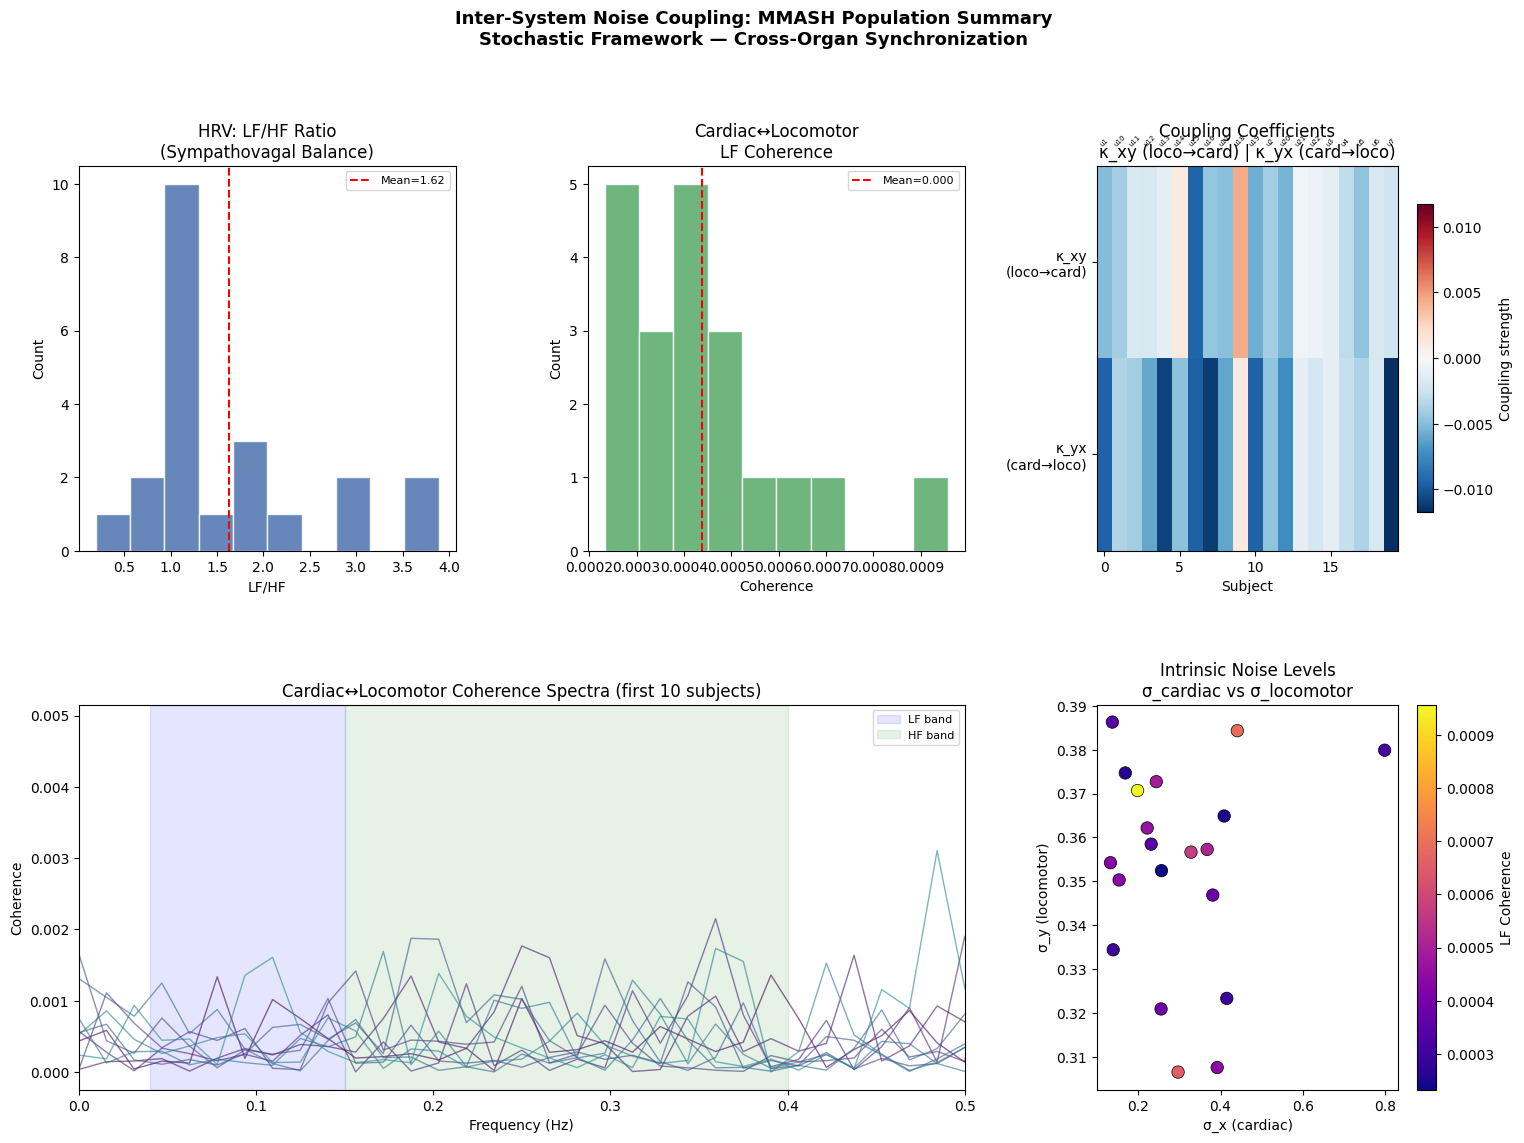

 Summary figure saved to ./results/population_summary.png


In [11]:
# Population Summary Visualization 

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Panel A: LF/HF ratio
ax1 = fig.add_subplot(gs[0, 0])
lf_hf_vals = df_spectral["LF_HF_ratio"].dropna()
ax1.hist(lf_hf_vals, bins=10, color="#4C72B0", edgecolor='white', alpha=0.85)
ax1.axvline(lf_hf_vals.mean(), color='red', linestyle='--',
            label=f'Mean={lf_hf_vals.mean():.2f}')
ax1.set(title="HRV: LF/HF Ratio\n(Sympathovagal Balance)",
        xlabel="LF/HF", ylabel="Count")
ax1.legend(fontsize=8)

# Panel B: LF Coherence
ax2 = fig.add_subplot(gs[0, 1])
coh_vals = [v["mean_LF_coherence"] for v in coherence_results.values()
            if not np.isnan(v["mean_LF_coherence"])]
ax2.hist(coh_vals, bins=10, color="#55A868", edgecolor='white', alpha=0.85)
ax2.axvline(np.mean(coh_vals), color='red', linestyle='--',
            label=f'Mean={np.mean(coh_vals):.3f}')
ax2.set(title="Cardiac↔Locomotor\nLF Coherence",
        xlabel="Coherence", ylabel="Count")
ax2.legend(fontsize=8)

# Panel C
ax3 = fig.add_subplot(gs[0, 2])
if len(df_ou) > 0:
    coupling_mat = df_ou[["kappa_xy","kappa_yx"]].values
    vmax = np.abs(coupling_mat).max()
    vmin = -vmax  # symmetric around 0
    im = ax3.imshow(coupling_mat.T, aspect='auto', cmap='RdBu_r',
                    vmin=vmin, vmax=vmax)
    ax3.set(title="Coupling Coefficients\nκ_xy (loco→card) | κ_yx (card→loco)",
            xlabel="Subject", yticks=[0,1],
            yticklabels=["κ_xy\n(loco→card)","κ_yx\n(card→loco)"])
    cb = plt.colorbar(im, ax=ax3, shrink=0.8)
    cb.set_label("Coupling strength")
    # Add subject labels
    for i, sid in enumerate(df_ou.index):
        ax3.text(i, -0.6, sid.replace("user_","u"),
                fontsize=5, ha='center', rotation=45)

# Panel D: Coherence spectra
ax4 = fig.add_subplot(gs[1, :2])
colors = plt.cm.viridis(np.linspace(0, 1, len(coherence_results)))
for (sid, cres), col in zip(list(coherence_results.items())[:10], colors):
    ax4.plot(cres["f"], cres["Cxy"], color=col, alpha=0.6, linewidth=1)
ax4.axvspan(0.04, 0.15, alpha=0.1, color='blue', label='LF band')
ax4.axvspan(0.15, 0.40, alpha=0.1, color='green', label='HF band')
ax4.set(title="Cardiac↔Locomotor Coherence Spectra (first 10 subjects)",
        xlabel="Frequency (Hz)", ylabel="Coherence", xlim=[0, 0.5])
ax4.legend(fontsize=8)

# Panel E: Noise levels
ax5 = fig.add_subplot(gs[1, 2])
if len(df_ou) > 0:
    scatter_coh = coh_vals[:len(df_ou)]
    sc = ax5.scatter(df_ou["sigma_x"], df_ou["sigma_y"],
                c=scatter_coh, cmap='plasma',
                s=80, edgecolors='k', linewidth=0.5)
    plt.colorbar(sc, ax=ax5, label='LF Coherence')
    ax5.set(title="Intrinsic Noise Levels\nσ_cardiac vs σ_locomotor",
            xlabel="σ_x (cardiac)", ylabel="σ_y (locomotor)")

plt.suptitle("Inter-System Noise Coupling: MMASH Population Summary\n"
             "Stochastic Framework — Cross-Organ Synchronization",
             fontsize=13, fontweight='bold', y=1.01)

plt.savefig(f"{RESULTS_PATH}population_summary.png",
            dpi=200, bbox_inches='tight')
plt.show()
print(f" Summary figure saved to {RESULTS_PATH}population_summary.png")

In [12]:
# COUPLED OU PROCESS 
# The bivariate coupled OU system:

#   dX = θ_x(−X)dt + κ_xy·Y·dt + σ_x·dW_x   ← cardiac
#   dY = θ_y(−Y)dt + κ_yx·X·dt + σ_y·dW_y   ← locomotor

# κ_xy : how much locomotion drives cardiac fluctuations
# κ_yx : how much cardiac drives locomotor fluctuations
# σ    : intrinsic noise 

def simulate_coupled_ou(kappa_xy=0.0, kappa_yx=0.0,
                        sigma_x=0.3, sigma_y=0.3,
                        theta_x=1.0, theta_y=1.0,
                        T=100, dt=0.01, seed=42):
    """Euler-Maruyama simulation of bivariate coupled OU process."""
    np.random.seed(seed)
    n     = int(T / dt)
    t     = np.linspace(0, T, n)
    X, Y  = np.zeros(n), np.zeros(n)
    sdt   = np.sqrt(dt)

    for i in range(1, n):
        dWx   = np.random.randn() * sdt
        dWy   = np.random.randn() * sdt
        X[i]  = X[i-1] + (-theta_x * X[i-1] + kappa_xy * Y[i-1]) * dt + sigma_x * dWx
        Y[i]  = Y[i-1] + (-theta_y * Y[i-1] + kappa_yx * X[i-1]) * dt + sigma_y * dWy

    return t, X, Y

# Pull REAL mean parameters from MMASH df_ou
mean_kxy = df_ou['kappa_xy'].mean()
mean_kyx = df_ou['kappa_yx'].mean()
mean_sx  = df_ou['sigma_x'].mean()
mean_sy  = df_ou['sigma_y'].mean()

print(" Real MMASH Population Parameters ")
print(f"  Mean κ_xy (loco → cardiac) : {mean_kxy:.5f}")
print(f"  Mean κ_yx (cardiac → loco) : {mean_kyx:.5f}")
print(f"  Mean σ_cardiac             : {mean_sx:.4f}")
print(f"  Mean σ_locomotor           : {mean_sy:.4f}")

# Most coupled subject (largest |κ_xy|)
top_subject = df_ou['kappa_xy'].abs().idxmax()
print(f"\n  Most coupled subject : {top_subject}")
print(f"    κ_xy = {df_ou.loc[top_subject,'kappa_xy']:.5f}")
print(f"    κ_yx = {df_ou.loc[top_subject,'kappa_yx']:.5f}")

 Real MMASH Population Parameters 
  Mean κ_xy (loco → cardiac) : -0.00282
  Mean κ_yx (cardiac → loco) : -0.00551
  Mean σ_cardiac             : 0.2982
  Mean σ_locomotor           : 0.3532

  Most coupled subject : user_15
    κ_xy = -0.00938
    κ_yx = -0.00958


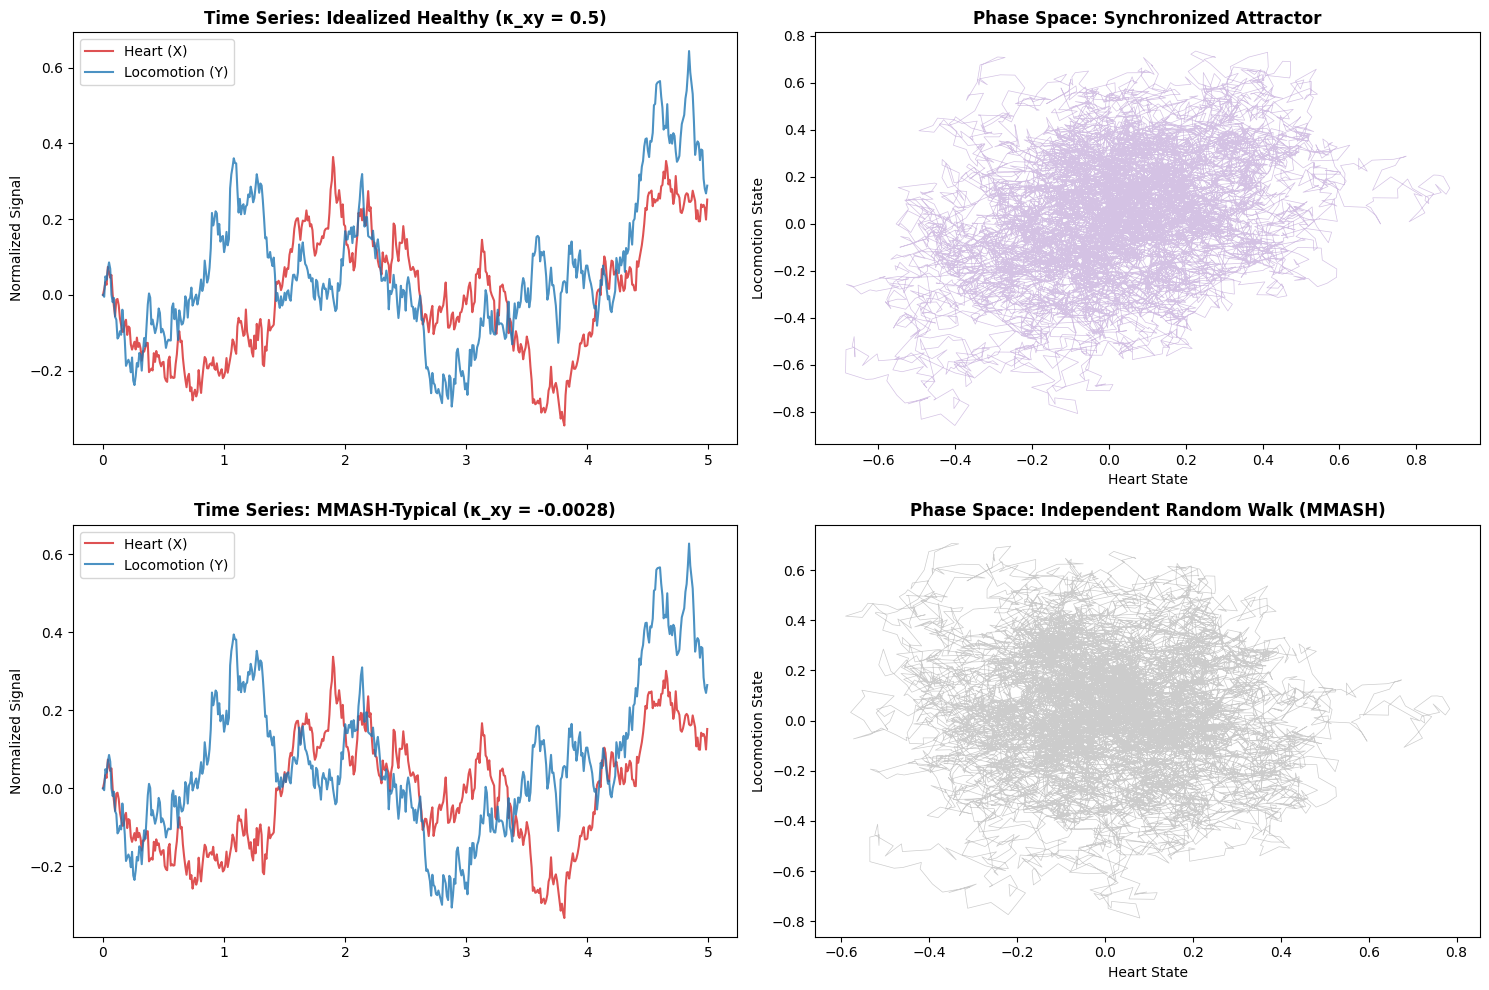

 Phase space saved


In [13]:
# PHASE SPACE - Real MMASH Params vs Idealized Healthy
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Scenario A: Strong coupling
t_h, X_h, Y_h = simulate_coupled_ou(
    kappa_xy=0.5, kappa_yx=0.3,
    sigma_x=mean_sx, sigma_y=mean_sy
)

# Scenario B: Real weak coupling
t_m, X_m, Y_m = simulate_coupled_ou(
    kappa_xy=mean_kxy, kappa_yx=mean_kyx,
    sigma_x=mean_sx,   sigma_y=mean_sy
)

N = 500  # plot first 500 steps for clarity

# Time series - healthy
axes[0,0].plot(t_h[:N], X_h[:N], color='#d62728', alpha=0.8, label='Heart (X)')
axes[0,0].plot(t_h[:N], Y_h[:N], color='#1f77b4', alpha=0.8, label='Locomotion (Y)')
axes[0,0].set_title("Time Series: Idealized Healthy (κ_xy = 0.5)", fontweight='bold')
axes[0,0].set_ylabel("Normalized Signal")
axes[0,0].legend()

# Phase space - healthy (compact attractor)
axes[0,1].plot(X_h, Y_h, color='#9467bd', alpha=0.4, linewidth=0.5)
axes[0,1].set_title("Phase Space: Synchronized Attractor", fontweight='bold')
axes[0,1].set_xlabel("Heart State")
axes[0,1].set_ylabel("Locomotion State")

# Time series - MMASH
axes[1,0].plot(t_m[:N], X_m[:N], color='#d62728', alpha=0.8, label='Heart (X)')
axes[1,0].plot(t_m[:N], Y_m[:N], color='#1f77b4', alpha=0.8, label='Locomotion (Y)')
axes[1,0].set_title(f"Time Series: MMASH-Typical (κ_xy = {mean_kxy:.4f})", fontweight='bold')
axes[1,0].set_ylabel("Normalized Signal")
axes[1,0].legend()

# Phase space - MMASH (diffuse cloud)
axes[1,1].plot(X_m, Y_m, color='gray', alpha=0.4, linewidth=0.5)
axes[1,1].set_title("Phase Space: Independent Random Walk (MMASH)", fontweight='bold')
axes[1,1].set_xlabel("Heart State")
axes[1,1].set_ylabel("Locomotion State")

plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}ou_phase_space_real.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Phase space saved")

In [14]:
# STATISTICAL VALIDATION - CROSS-CORRELATION

from scipy.signal import correlate

def max_cross_correlation(x, y):
    x_n = (x - x.mean()) / (x.std() * len(x))
    y_n = (y - y.mean()) / y.std()
    corr = correlate(x_n, y_n, mode='full')
    lags = np.arange(-(len(x)-1), len(x))
    return np.max(corr), lags[np.argmax(corr)]

corr_h, lag_h = max_cross_correlation(X_h, Y_h)
corr_m, lag_m = max_cross_correlation(X_m, Y_m)

print(" Cross-Correlation Validation ")
print(f"  Idealized Healthy : max corr = {corr_h:.4f}  (lag = {lag_h})")
print(f"  MMASH-Typical     : max corr = {corr_m:.4f}  (lag = {lag_m})")
print(f"\n  Ratio: {corr_h/corr_m:.1f}× higher in coupled/healthy state")
print("\nInterpretation: Higher correlation in the healthy state confirms")
print("that coupling creates measurable synchrony in the OU framework.")

 Cross-Correlation Validation 
  Idealized Healthy : max corr = 0.4224  (lag = 89)
  MMASH-Typical     : max corr = 0.2045  (lag = 254)

  Ratio: 2.1× higher in coupled/healthy state

Interpretation: Higher correlation in the healthy state confirms
that coupling creates measurable synchrony in the OU framework.


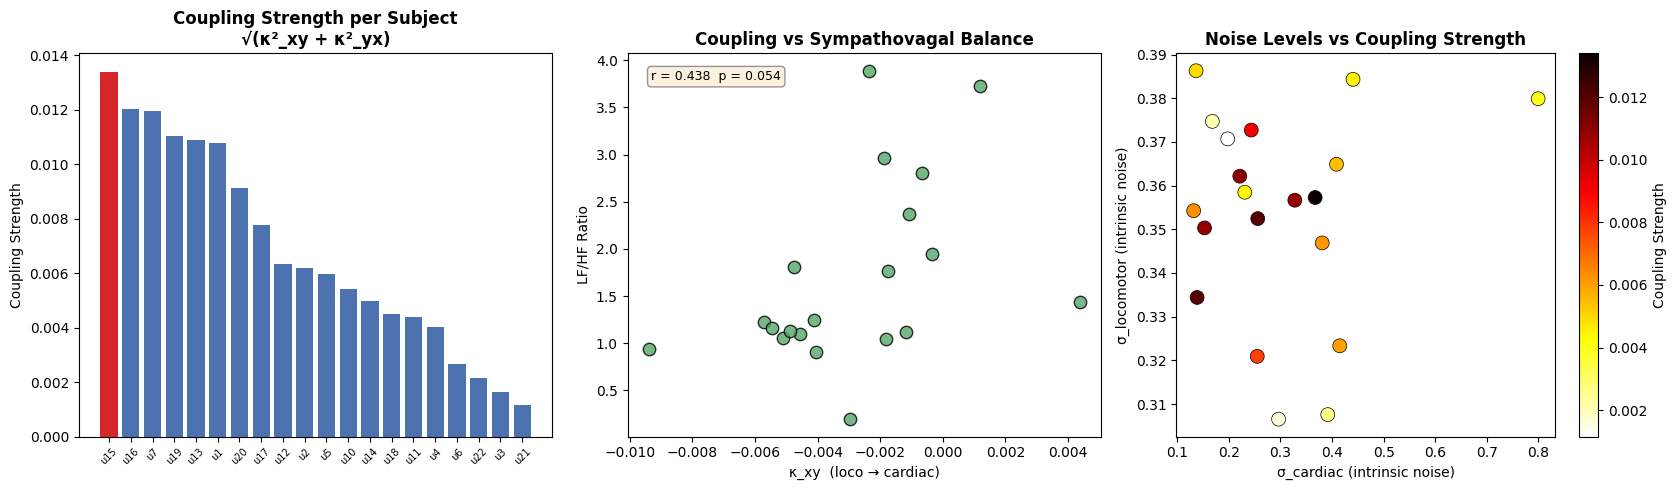

       kappa_xy  kappa_yx   sigma_x   sigma_y  coupling_strength
count  20.00000  20.00000  20.00000  20.00000           20.00000
mean   -0.00282  -0.00551   0.29816   0.35323            0.00682
std     0.00295   0.00381   0.15611   0.02384            0.00382
min    -0.00938  -0.01174   0.13201   0.30653            0.00115
25%    -0.00478  -0.00946   0.19052   0.34376            0.00430
50%    -0.00265  -0.00476   0.25571   0.35696            0.00608
75%    -0.00115  -0.00256   0.38376   0.37120            0.01081
max     0.00437   0.00105   0.79949   0.38629            0.01341


In [15]:
# POPULATION COUPLING ANALYSIS 

from scipy.stats import pearsonr

# Compute overall coupling strength per subject
df_ou['coupling_strength'] = np.sqrt(df_ou['kappa_xy']**2 + df_ou['kappa_yx']**2)
df_sorted = df_ou.sort_values('coupling_strength', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1: Coupling strength ranked
colors = ['#d62728' if i == 0 else '#4C72B0' for i in range(len(df_sorted))]
axes[0].bar(range(len(df_sorted)), df_sorted['coupling_strength'], color=colors)
axes[0].set_xticks(range(len(df_sorted)))
axes[0].set_xticklabels([s.replace('user_','u') for s in df_sorted.index],
                         rotation=45, fontsize=7)
axes[0].set_title("Coupling Strength per Subject\n√(κ²_xy + κ²_yx)", fontweight='bold')
axes[0].set_ylabel("Coupling Strength")

# Plot 2: κ_xy vs LF/HF ratio
df_merged = df_ou.join(df_spectral[['LF_HF_ratio']], how='inner').dropna()
axes[1].scatter(df_merged['kappa_xy'], df_merged['LF_HF_ratio'],
                s=80, alpha=0.8, color='#55A868', edgecolors='k')
r, p = pearsonr(df_merged['kappa_xy'], df_merged['LF_HF_ratio'])
axes[1].set_xlabel("κ_xy  (loco → cardiac)")
axes[1].set_ylabel("LF/HF Ratio")
axes[1].set_title("Coupling vs Sympathovagal Balance", fontweight='bold')
axes[1].text(0.05, 0.93, f"r = {r:.3f}  p = {p:.3f}",
             transform=axes[1].transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

# Plot 3: Noise levels coloured by coupling
sc = axes[2].scatter(df_ou['sigma_x'], df_ou['sigma_y'],
                     c=df_ou['coupling_strength'], cmap='hot_r',
                     s=100, edgecolors='k', linewidth=0.5)
plt.colorbar(sc, ax=axes[2], label='Coupling Strength')
axes[2].set_xlabel("σ_cardiac (intrinsic noise)")
axes[2].set_ylabel("σ_locomotor (intrinsic noise)")
axes[2].set_title("Noise Levels vs Coupling Strength", fontweight='bold')

plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}coupling_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print(df_ou[['kappa_xy','kappa_yx','sigma_x','sigma_y','coupling_strength']].describe().round(5))

In [16]:
# EXPORT BRIDGE TO MIMIC-IV

import pandas as pd

# Build full feature table
coh_series = pd.Series(
    {k: v['mean_LF_coherence'] for k, v in coherence_results.items()},
    name='mean_LF_coherence'
)

df_export = df_ou[['kappa_xy','kappa_yx','sigma_x','sigma_y','coupling_strength']].copy()
df_export = df_export.join(df_spectral[['LF_HF_ratio']], how='left')
df_export = df_export.join(coh_series, how='left')
df_export['dataset']      = 'MMASH'
df_export['health_state'] = 'healthy'

df_export.to_csv(f"{RESULTS_PATH}mmash_features.csv")

print(" MMASH feature set exported")
print(f"   Shape : {df_export.shape}")
print(f"   Path  : {RESULTS_PATH}mmash_features.csv")
print("\nPreview:")
print(df_export.head())
print("\n These features will be extracted from MIMIC-IV for healthy vs disease comparison.")

 MMASH feature set exported
   Shape : (20, 9)
   Path  : ./results/mmash_features.csv

Preview:
         kappa_xy  kappa_yx   sigma_x   sigma_y  coupling_strength  \
user_1  -0.005091 -0.009500  0.328037  0.356656           0.010778   
user_10 -0.004120 -0.003539  0.408791  0.364886           0.005431   
user_11 -0.001744 -0.004039  0.231093  0.358476           0.004399   
user_12 -0.001871 -0.006044  0.132009  0.354245           0.006327   
user_13 -0.001068 -0.010855  0.153086  0.350316           0.010907   

         LF_HF_ratio  mean_LF_coherence dataset health_state  
user_1      1.057806           0.000578   MMASH      healthy  
user_10     1.243915           0.000245   MMASH      healthy  
user_11     1.769771           0.000353   MMASH      healthy  
user_12     2.964007           0.000431   MMASH      healthy  
user_13     2.367837           0.000441   MMASH      healthy  

 These features will be extracted from MIMIC-IV for healthy vs disease comparison.


In [17]:
# Transfer Entropy 
# this is model-free and captures non-linear coupling.

from collections import Counter

def discretize(x, n_bins=6):
    """Equal-frequency binning (quantile-based) for continuous signals."""
    quantiles = np.linspace(0, 100, n_bins + 1)
    bins      = np.unique(np.percentile(x, quantiles))
    return np.digitize(x, bins[1:-1])

def transfer_entropy(source, target, lag=1, n_bins=6):
    """
    TE from source → target.
    Positive value = source helps predict target.
    """
    src = discretize(source, n_bins)
    tgt = discretize(target, n_bins)

    n        = len(tgt) - lag
    t_future = tgt[lag:]   # target at t+1
    t_past   = tgt[:n]     # target at t
    s_past   = src[:n]     # source at t

    joint_3  = {}   # P(t_future, t_past, s_past)
    joint_ts = {}   # P(t_future, t_past)
    joint_ps = {}   # P(t_past,   s_past)
    marg_p   = {}   # P(t_past)

    for tf, tp, sp in zip(t_future, t_past, s_past):
        joint_3[ (tf, tp, sp)] = joint_3.get( (tf, tp, sp), 0) + 1
        joint_ts[(tf, tp)]     = joint_ts.get((tf, tp),     0) + 1
        joint_ps[(tp, sp)]     = joint_ps.get((tp, sp),     0) + 1
        marg_p[tp]             = marg_p.get(tp,             0) + 1

    te = 0.0
    for (tf, tp, sp), cnt in joint_3.items():
        p_all             = cnt / n
        p_tf_given_tp_sp  = cnt / joint_ps[(tp, sp)]
        p_tf_given_tp     = joint_ts[(tf, tp)] / marg_p[tp]
        if p_tf_given_tp > 0 and p_tf_given_tp_sp > 0:
            te += p_all * np.log2(p_tf_given_tp_sp / p_tf_given_tp)

    return max(te, 0.0)

# Loop through subjects, extract signals, compute TE
dt       = 1.0 / FS_RR
te_results  = {}
signals_dict = {}   # store standardized signals for later cells

for sid in coherence_results:
    try:
        rr_ts   = hrv_series[sid]["rr"]
        t_rr    = hrv_series[sid]["time"]
        accel   = accel_data[sid]
        t_accel = accel["time_s"].values
        mag     = accel["magnitude"].values

        t_start  = max(t_rr[0],  t_accel[0])
        t_end    = min(t_rr[-1], t_accel[-1])
        t_common = np.arange(t_start, t_end, dt)

        if len(t_common) < 500:
            continue

        rr_i  = interp1d(t_rr,    rr_ts, bounds_error=False,
                         fill_value='extrapolate')(t_common)
        acc_i = interp1d(t_accel, mag,   bounds_error=False,
                         fill_value='extrapolate')(t_common)

        rr_z  = (rr_i  - rr_i.mean())  / rr_i.std()
        acc_z = (acc_i - acc_i.mean()) / acc_i.std()

        # Store for later
        signals_dict[sid] = {"rr_z": rr_z, "acc_z": acc_z,
                             "t": t_common}

        # Transfer entropy both directions
        te_loco_to_card = transfer_entropy(acc_z, rr_z,  lag=1)
        te_card_to_loco = transfer_entropy(rr_z,  acc_z, lag=1)

        te_results[sid] = {
            "TE_loco_to_card": te_loco_to_card,
            "TE_card_to_loco": te_card_to_loco,
            "TE_net":          te_loco_to_card - te_card_to_loco
        }
        print(f"  {sid}  TE(loco→card)={te_loco_to_card:.4f}  "
              f"TE(card→loco)={te_card_to_loco:.4f}")

    except Exception as e:
        print(f"  {sid} ❌ {e}")

df_te = pd.DataFrame(te_results).T
print(f"\n✅ Transfer entropy computed: {len(df_te)} subjects")
print(df_te.round(5).describe())
df_te.to_csv(f"{RESULTS_PATH}transfer_entropy.csv")

  user_1  TE(loco→card)=0.0007  TE(card→loco)=0.0007
  user_10  TE(loco→card)=0.0005  TE(card→loco)=0.0006
  user_11  TE(loco→card)=0.0004  TE(card→loco)=0.0011
  user_12  TE(loco→card)=0.0013  TE(card→loco)=0.0018
  user_13  TE(loco→card)=0.0004  TE(card→loco)=0.0017
  user_14  TE(loco→card)=0.0005  TE(card→loco)=0.0007
  user_15  TE(loco→card)=0.0044  TE(card→loco)=0.0011
  user_16  TE(loco→card)=0.0009  TE(card→loco)=0.0017
  user_17  TE(loco→card)=0.0016  TE(card→loco)=0.0012
  user_18  TE(loco→card)=0.0004  TE(card→loco)=0.0002
  user_19  TE(loco→card)=0.0010  TE(card→loco)=0.0022
  user_2  TE(loco→card)=0.0005  TE(card→loco)=0.0008
  user_20  TE(loco→card)=0.0004  TE(card→loco)=0.0007
  user_21  TE(loco→card)=0.0005  TE(card→loco)=0.0004
  user_22  TE(loco→card)=0.0005  TE(card→loco)=0.0011
  user_3  TE(loco→card)=0.0021  TE(card→loco)=0.0017
  user_4  TE(loco→card)=0.0028  TE(card→loco)=0.0002
  user_5  TE(loco→card)=0.0007  TE(card→loco)=0.0003
  user_6  TE(loco→card)=0.0011  T

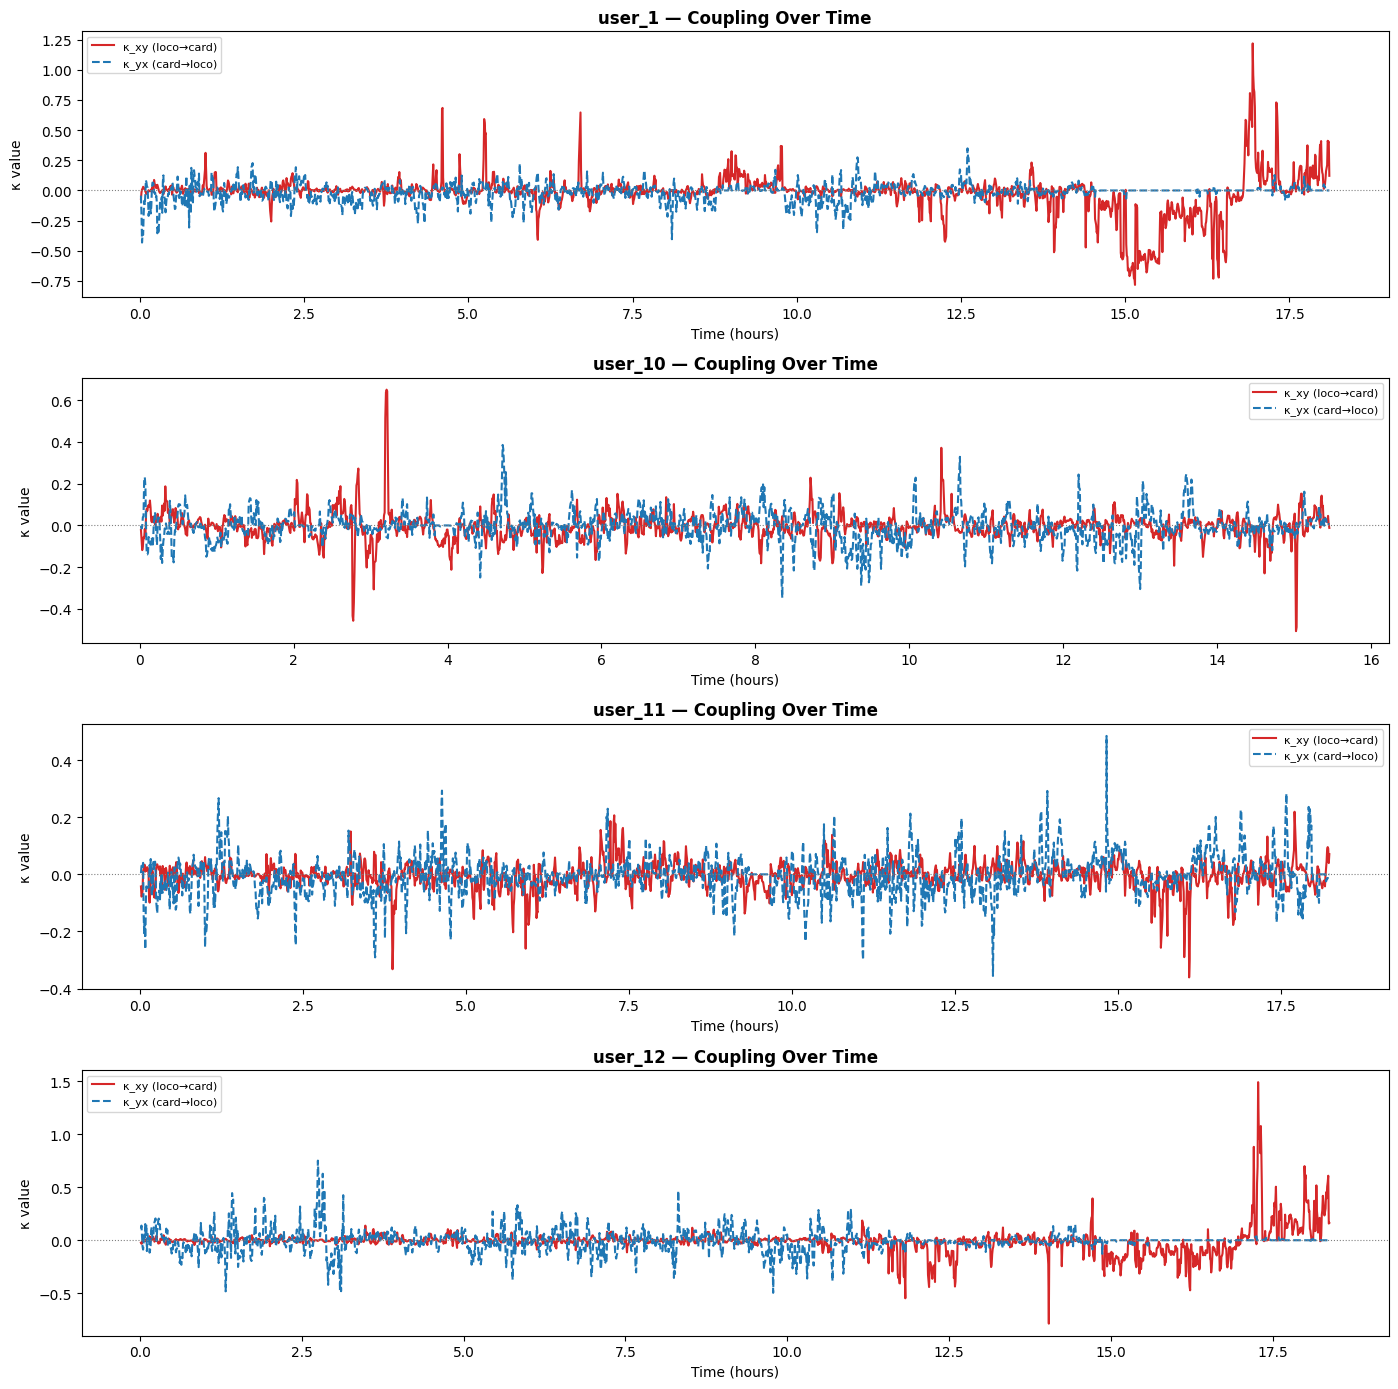

Coupling variability across subjects:
         mean_kxy  std_kxy    cv_kxy
user_1   -0.02071  0.16199   7.81980
user_10  -0.00378  0.06718  17.75364
user_11  -0.00430  0.04554  10.59643
user_12  -0.00706  0.11759  16.65243
user_13  -0.02068  0.09607   4.64598
user_14  -0.00168  0.06394  38.04530
user_15   0.05986  0.53004   8.85482
user_16  -0.03009  0.15208   5.05422
user_17  -0.03457  0.24821   7.17935
user_18   0.01330  0.16123  12.12205
user_19  -0.03829  0.12202   3.18690
user_2    0.01000  0.12419  12.41785
user_20  -0.00678  0.08975  13.23670
user_21  -0.00190  0.07433  39.17103
user_22  -0.00646  0.08065  12.48120
user_3   -0.00972  0.16864  17.34114
user_4   -0.00434  0.13192  30.40352
user_5    0.04586  0.31711   6.91519
user_6    0.00705  0.22090  31.33970
user_7   -0.02036  0.07018   3.44675
 Windowed coupling done


In [18]:
# Windowed OU Coupling — How k changes over time

# A stable k = consistent coupling. Fluctuating k = dynamic regulation.

def windowed_coupling(rr_z, acc_z, dt,
                      window_sec=120, step_sec=30):
    """
    Sliding window OU coupling.
    window_sec: window length in seconds
    step_sec  : step size in seconds
    """
    fs          = int(1.0 / dt)
    window_size = window_sec * fs
    step_size   = step_sec   * fs
    n           = min(len(rr_z), len(acc_z))
    records     = []

    for start in range(0, n - window_size, step_size):
        end  = start + window_size
        x_w  = rr_z[start:end]
        y_w  = acc_z[start:end]
        try:
            params = fit_ou_coupling(x_w, y_w, dt)
            records.append({
                "t_center"  : (start + window_size // 2) * dt,
                "kappa_xy"  : params[2],
                "kappa_yx"  : params[3],
                "sigma_x"   : params[4],
                "sigma_y"   : params[5],
                "coupling_s": np.sqrt(params[2]**2 + params[3]**2)
            })
        except:
            pass

    return pd.DataFrame(records)

# --- Run for all subjects & pick 4 for plotting ---
window_results = {}
for sid, sigs in signals_dict.items():
    wdf = windowed_coupling(sigs["rr_z"], sigs["acc_z"], dt)
    if len(wdf) > 5:
        window_results[sid] = wdf

# Plot first 4 subjects
plot_sids = list(window_results.keys())[:4]
fig, axes = plt.subplots(len(plot_sids), 1,
                         figsize=(14, 3.5 * len(plot_sids)),
                         sharex=False)
if len(plot_sids) == 1:
    axes = [axes]

for ax, sid in zip(axes, plot_sids):
    wdf = window_results[sid]
    ax.plot(wdf["t_center"] / 3600, wdf["kappa_xy"],
            color='#d62728', label='κ_xy (loco→card)', linewidth=1.5)
    ax.plot(wdf["t_center"] / 3600, wdf["kappa_yx"],
            color='#1f77b4', label='κ_yx (card→loco)',
            linewidth=1.5, linestyle='--')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_title(f"{sid} — Coupling Over Time", fontweight='bold')
    ax.set_ylabel("κ value")
    ax.set_xlabel("Time (hours)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}windowed_coupling.png", dpi=150,
            bbox_inches='tight')
plt.show()

# Summary: coupling variability per subject
coupling_variability = {
    sid: {"mean_kxy"  : wdf["kappa_xy"].mean(),
          "std_kxy"   : wdf["kappa_xy"].std(),
          "cv_kxy"    : wdf["kappa_xy"].std() / (abs(wdf["kappa_xy"].mean()) + 1e-9)}
    for sid, wdf in window_results.items()
}
df_windowed = pd.DataFrame(coupling_variability).T
print("Coupling variability across subjects:")
print(df_windowed.round(5))
df_windowed.to_csv(f"{RESULTS_PATH}windowed_coupling_stats.csv")
print(" Windowed coupling done")

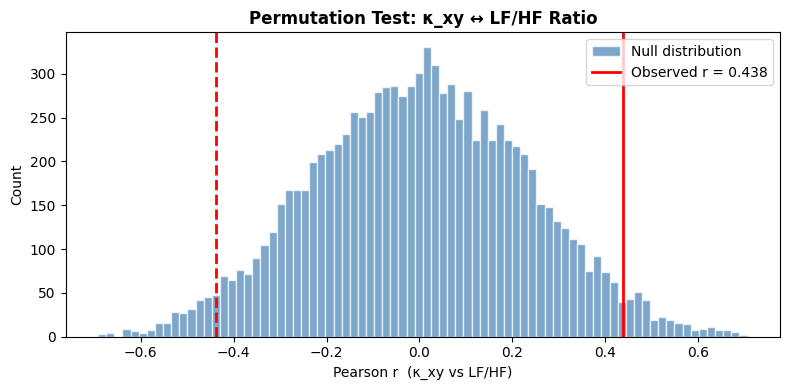

 Permutation Test Results 
  Observed r          : 0.4378
  Standard p-value    : 0.0536
  Permutation p-value : 0.0545  (n=10,000 shuffles)
    Trend present but not significant - more subjects needed


In [19]:
# Permutation Test
# With n=20, standard p-values are unreliable.

from scipy.stats import pearsonr

df_perm = df_ou.join(df_spectral[['LF_HF_ratio']], how='inner').dropna()
kxy_vals  = df_perm['kappa_xy'].values
lfhf_vals = df_perm['LF_HF_ratio'].values

# Observed correlation
r_obs, p_standard = pearsonr(kxy_vals, lfhf_vals)

# Permutation distribution
n_perms = 10_000
r_null  = np.zeros(n_perms)
rng     = np.random.default_rng(42)

for i in range(n_perms):
    shuffled  = rng.permutation(lfhf_vals)
    r_null[i] = pearsonr(kxy_vals, shuffled)[0]

p_perm = np.mean(np.abs(r_null) >= np.abs(r_obs))

# Plot null distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(r_null, bins=80, color='steelblue', alpha=0.7,
        edgecolor='white', label='Null distribution')
ax.axvline( r_obs, color='red',  linewidth=2,
            label=f'Observed r = {r_obs:.3f}')
ax.axvline(-r_obs, color='red',  linewidth=2, linestyle='--')
ax.set_xlabel("Pearson r  (κ_xy vs LF/HF)")
ax.set_ylabel("Count")
ax.set_title("Permutation Test: κ_xy ↔ LF/HF Ratio", fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}permutation_test.png", dpi=150,
            bbox_inches='tight')
plt.show()

print(" Permutation Test Results ")
print(f"  Observed r          : {r_obs:.4f}")
print(f"  Standard p-value    : {p_standard:.4f}")
print(f"  Permutation p-value : {p_perm:.4f}  (n={n_perms:,} shuffles)")
if p_perm < 0.05:
    print("   Result holds - coupling correlates with sympathovagal balance")
else:
    print("    Trend present but not significant - more subjects needed")

In [20]:
# FINAL MMASH SUMMARY
df_final = df_ou[['kappa_xy','kappa_yx','sigma_x',
                   'sigma_y','coupling_strength']].copy()
df_final = df_final.join(df_spectral[['LF_HF_ratio']], how='left')
df_final = df_final.join(df_te[['TE_loco_to_card',
                                 'TE_card_to_loco',
                                 'TE_net']], how='left')
df_final = df_final.join(df_windowed[['std_kxy']], how='left')
df_final['dataset']      = 'MMASH'
df_final['health_state'] = 'healthy'

df_final.to_csv(f"{RESULTS_PATH}mmash_final_features.csv")

print(" MMASH Final Feature Set ")
print(f"  Subjects : {len(df_final)}")
print(f"  Features : {df_final.shape[1]}")
print("\n", df_final.round(5).to_string())
print(f"\n Saved to {RESULTS_PATH}mmash_final_features.csv")

 MMASH Final Feature Set 
  Subjects : 20
  Features : 12

          kappa_xy  kappa_yx  sigma_x  sigma_y  coupling_strength  LF_HF_ratio  TE_loco_to_card  TE_card_to_loco   TE_net  std_kxy dataset health_state
user_1   -0.00509  -0.00950  0.32804  0.35666            0.01078      1.05781          0.00072          0.00069  0.00003  0.16199   MMASH      healthy
user_10  -0.00412  -0.00354  0.40879  0.36489            0.00543      1.24391          0.00051          0.00060 -0.00010  0.06718   MMASH      healthy
user_11  -0.00174  -0.00404  0.23109  0.35848            0.00440      1.76977          0.00043          0.00106 -0.00063  0.04554   MMASH      healthy
user_12  -0.00187  -0.00604  0.13201  0.35425            0.00633      2.96401          0.00134          0.00182 -0.00048  0.11759   MMASH      healthy
user_13  -0.00107  -0.01086  0.15309  0.35032            0.01091      2.36784          0.00041          0.00166 -0.00125  0.09607   MMASH      healthy
user_14   0.00119  -0.00484  0.136